<div style = "color: white; font-size: 30px; margin-bottom: 50px; text-align:center">
    Applied Finance
  </div>

<div style = "color: white; font-size: 30px; margin-bottom: 10px; text-align:center">
    Home-taken Project
  </div>

  <div style = "color: white; font-size: 30px; margin-bottom: 10px; text-align:center">
    EUR/PLN Trading Strategy
  </div>

Name: Tsoi Kwan Ma

Student ID: 476914

Student Email: t.ma@student.uw.edu.pl

In this project, there is an analysis on the tick-by-tick historical data for the EUR/PLN exchange rate covering the period from 1 September 2025, 00:00 to 6 October 2025, 00:00 obtained from freely available and non-commercial data sources. Since the foreign exchange market is one of the most liquid and dynamic financial environments, the price movements there often includes the features of volatility clustering, heavy tails and non-linear dependencies. 

In order to address the volatility structure of tick-level exchange-rate data, a volatility based GARCH model is used. It allows for dynamic forecasting of volatility and enables specific trading rule responsive to real-time changes in market conditions, which are the short-term momentum and mean-reverting signals.

The following mainly contains two big parts. First and foremost, there is an exploratory analysis of the tick data, for example price trends and distributions of the prices, followed by the stationarity testing and diagnostics for ARCH/GARCH effects. Afterwards, based on the insights drawn from the data and the methodology covered during the course, a technically correct and relatively original trading strategy is constructed. The out-sample data is based on the last two weeks of the sample (22 September – 6 October 2025). The strategy used will be capable of generating positive profit-and-loss (P&L) over that period, with the real-life example using the contract from HF Markets.

**The net profit for the target time period in the project will be 350 PLN and the Sharpe ratio is 0.64**, which is close to 1 and means that it is generating a reasonable return for the level of risk (volatility) taken.

At the end, there is also a discussion of the profit and loss changes and result of the **Sharpe ratio 0.22** when the point value equals to 1. **The net profit is 0.0011 PLN.**

## 1. Libraries

In [2]:
from datetime import datetime, timedelta
import dukascopy_python # https://pypi.org/project/dukascopy-python/
import pytz
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import het_arch
import scipy.stats as stats
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

## 2. Data Extraction

The tick-by-tick historical data for the EUR/PLN exchange rate is retreived from the Dukascopy, which is a non-commericial and free access financial bank platform, with the support of the Dukascopy Python library (reference: https://pypi.org/project/dukascopy-python/). The time window for data extraction is definded as the target of the project.

In [3]:
df = dukascopy_python.fetch(
    instrument = "EUR/PLN",
    interval = dukascopy_python.INTERVAL_TICK,
    offer_side = dukascopy_python.OFFER_SIDE_BID,
    start = datetime(2025, 9, 1),
    end = datetime(2025, 10, 6),
)

INFO:DUKASCRIPT:current timestamp :2025-09-02T09:50:06.271000
INFO:DUKASCRIPT:current timestamp :2025-09-03T09:50:14.502000
INFO:DUKASCRIPT:current timestamp :2025-09-04T14:34:37.816000
INFO:DUKASCRIPT:current timestamp :2025-09-05T16:20:15.718000
INFO:DUKASCRIPT:current timestamp :2025-09-09T01:44:29.888000
INFO:DUKASCRIPT:current timestamp :2025-09-10T00:28:17.418000
INFO:DUKASCRIPT:current timestamp :2025-09-11T08:16:01.706000
INFO:DUKASCRIPT:current timestamp :2025-09-12T12:35:55.457000
INFO:DUKASCRIPT:current timestamp :2025-09-16T16:10:10.035000
INFO:DUKASCRIPT:current timestamp :2025-09-18T04:29:09.735000
INFO:DUKASCRIPT:current timestamp :2025-09-19T14:06:23.449000
INFO:DUKASCRIPT:current timestamp :2025-09-22T19:00:56.460000
INFO:DUKASCRIPT:current timestamp :2025-09-23T16:11:58.508000
INFO:DUKASCRIPT:current timestamp :2025-09-25T01:05:18.162000
INFO:DUKASCRIPT:current timestamp :2025-09-25T20:55:03.557000
INFO:DUKASCRIPT:current timestamp :2025-09-29T04:13:09.684000
INFO:DUK

In [4]:
print(df.head())

                                  bidPrice  askPrice  bidVolume  askVolume
timestamp                                                                 
2025-08-31 22:00:01.268000+00:00   4.26094   4.26485       0.09       0.09
2025-08-31 22:00:01.319000+00:00   4.26095   4.26584       0.09       0.90
2025-08-31 22:00:01.370000+00:00   4.26094   4.26570       0.09       0.90
2025-08-31 22:00:01.521000+00:00   4.26094   4.26556       0.09       0.90
2025-08-31 22:00:03.375000+00:00   4.26094   4.26539       0.09       0.90


Since Dukascopy data is normally provided in UTC, it would be better to convert the timestamp index of the DataFrame from UTC to the GMT−2 time zone, which is also the local time in Warsaw, Poland.

In [5]:
df.index = df.index.tz_convert('Etc/GMT-2')

## 3. Data Processing

After downloading the raw tick-by-tick EUR/PLN data, the next step is to clean and rename the data, extract essential price information, and aggregate the high-frequency data into a suitable time interval for better statistical modelling.

In [6]:
df = df[["bidPrice", "askPrice"]]

df = df.rename(columns = {
    'bidPrice': 'bid',
    'askPrice': 'ask'
})

df.index.name = "time"
df.index = df.index.tz_localize(None)

Here, two additional features are computed which are spread and mid price. Mid price is calculated and used since it underlies the fair value of the currency at each particular time point. It should be used for volatility modelling because it is less noisy than raw bid or ask prices. It is believed that mid price could give a much cleaner signal of the true price movement which is what is want for forecasting.

In [7]:
df['spread'] = df['ask'] - df['bid']
df['mid'] = (df['ask'] + df['bid']) / 2

In [8]:
print(df.head())

                             bid      ask   spread       mid
time                                                        
2025-09-01 00:00:01.268  4.26094  4.26485  0.00391  4.262895
2025-09-01 00:00:01.319  4.26095  4.26584  0.00489  4.263395
2025-09-01 00:00:01.370  4.26094  4.26570  0.00476  4.263320
2025-09-01 00:00:01.521  4.26094  4.26556  0.00462  4.263250
2025-09-01 00:00:03.375  4.26094  4.26539  0.00445  4.263165


In [9]:
print(df.info())
print(df.index)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 595830 entries, 2025-09-01 00:00:01.268000 to 2025-10-05 23:59:59.352000
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   bid     595830 non-null  float64
 1   ask     595830 non-null  float64
 2   spread  595830 non-null  float64
 3   mid     595830 non-null  float64
dtypes: float64(4)
memory usage: 22.7 MB
None
DatetimeIndex(['2025-09-01 00:00:01.268000', '2025-09-01 00:00:01.319000',
               '2025-09-01 00:00:01.370000', '2025-09-01 00:00:01.521000',
               '2025-09-01 00:00:03.375000', '2025-09-01 00:00:06.133000',
               '2025-09-01 00:00:06.284000', '2025-09-01 00:00:06.387000',
               '2025-09-01 00:00:06.487000', '2025-09-01 00:00:06.538000',
               ...
               '2025-10-05 23:45:39.350000', '2025-10-05 23:45:52.185000',
               '2025-10-05 23:46:08.804000', '2025-10-05 23:46:52.203000',
               '2025-10-

In [10]:
df.isna().sum() # check if there is any missing data

bid       0
ask       0
spread    0
mid       0
dtype: int64

For each 30-minute interval, the last observed value of bid, ask, spread, and mid is taken. Forward filling is not used becaues of avoiding artificial creation of price values that never actually occurred. It may midlead the market signal and activities. And then the data is splitted into training and testing periods.

In [11]:
# aggregating the data to 30-minute intervals
df = df.resample('30min').agg({'bid': 'last', 'ask': 'last', 'spread': 'last', 'mid': 'last'})
print(df.head())

                         bid      ask   spread       mid
time                                                    
2025-09-01 00:00:00  4.25996  4.26346  0.00350  4.261710
2025-09-01 00:30:00  4.26010  4.26469  0.00459  4.262395
2025-09-01 01:00:00  4.25985  4.26336  0.00351  4.261605
2025-09-01 01:30:00  4.26056  4.26339  0.00283  4.261975
2025-09-01 02:00:00  4.26104  4.26306  0.00202  4.262050


In [12]:
test_start = "2025-09-22 00:00:000"
test_end   = "2025-10-06 00:00:000"

train = df[df.index < test_start]
test = df[(df.index >= test_start) & (df.index < test_end)]

In [13]:
print("Train period:", train.index.min(), train.index.max(), len(train))
print("Test period:", test.index.min(), test.index.max(), len(test))

Train period: 2025-09-01 00:00:00 2025-09-21 23:30:00 1008
Test period: 2025-09-22 00:00:00 2025-10-05 23:30:00 672


## 4. Data Inspection

The followings are the visualizations on the ask, bid, mid, and spread prices from the train (in-sample) set. It shows that the differences on logarithmic returns are more stationary than the originals.

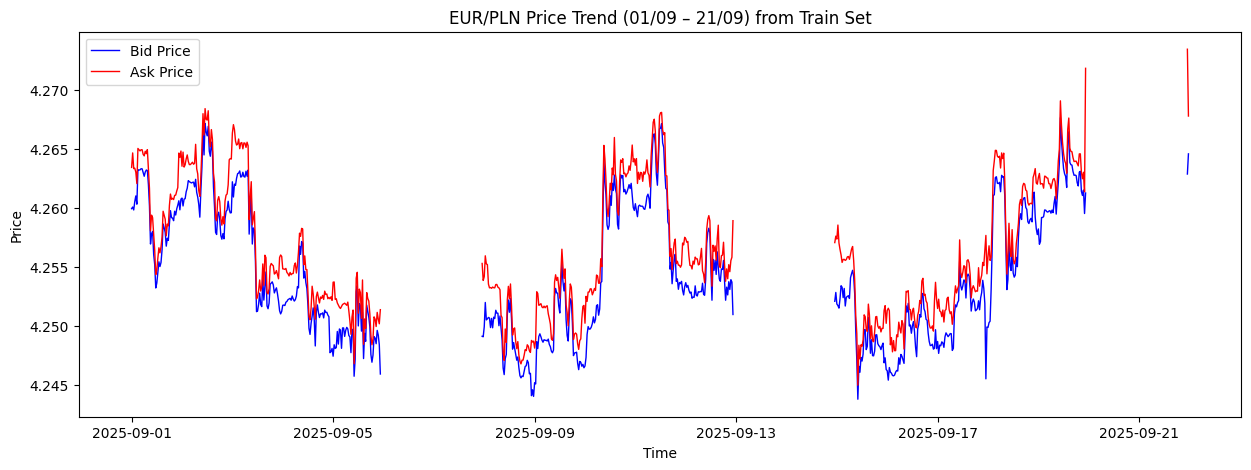

In [14]:
plt.figure(figsize = (15,5))
plt.plot(train.index, train['bid'], label = 'Bid Price', color = 'blue', linewidth = 1)
plt.plot(train.index, train['ask'], label = 'Ask Price', color = 'red', linewidth = 1)

plt.title('EUR/PLN Price Trend (01/09 – 21/09) from Train Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

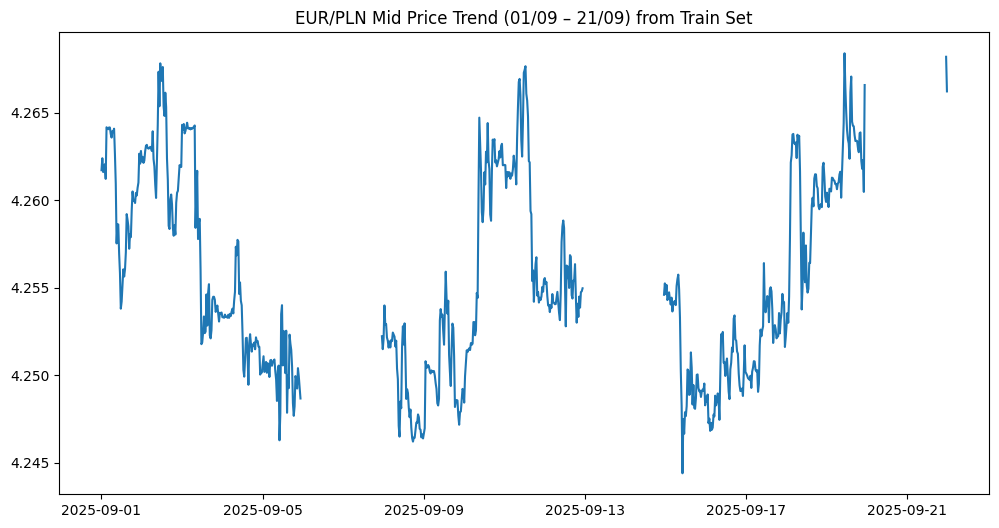

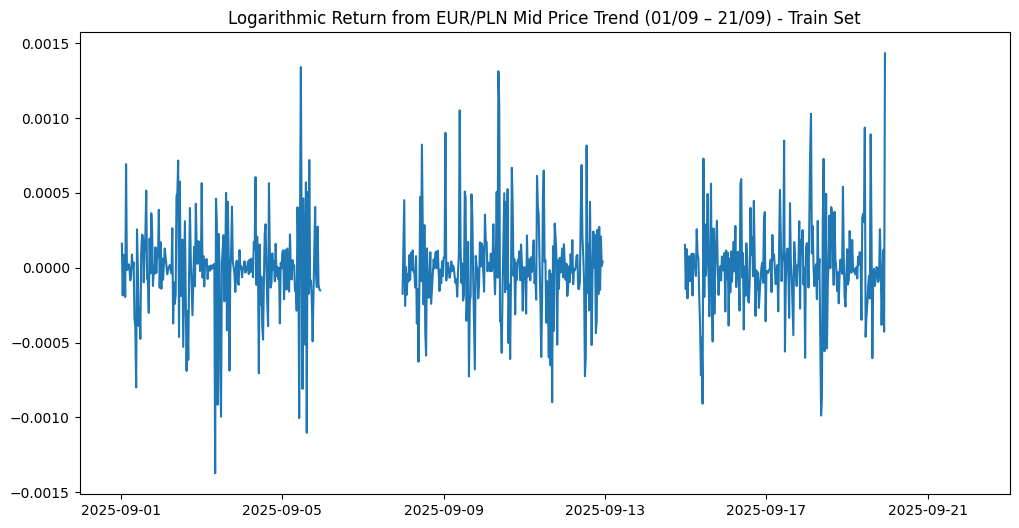

In [15]:
plt.figure(figsize = (12, 6))
plt.plot(train['mid'])
plt.title('EUR/PLN Mid Price Trend (01/09 – 21/09) from Train Set')
plt.show()

plt.figure(figsize = (12, 6))
plt.plot(np.log(train['mid']).diff())
plt.title('Logarithmic Return from EUR/PLN Mid Price Trend (01/09 – 21/09) - Train Set')
plt.show()

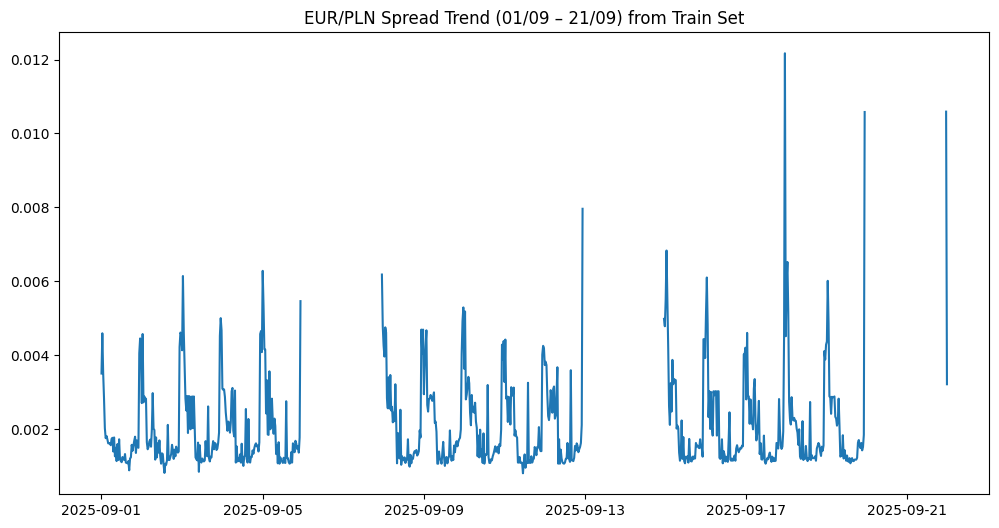

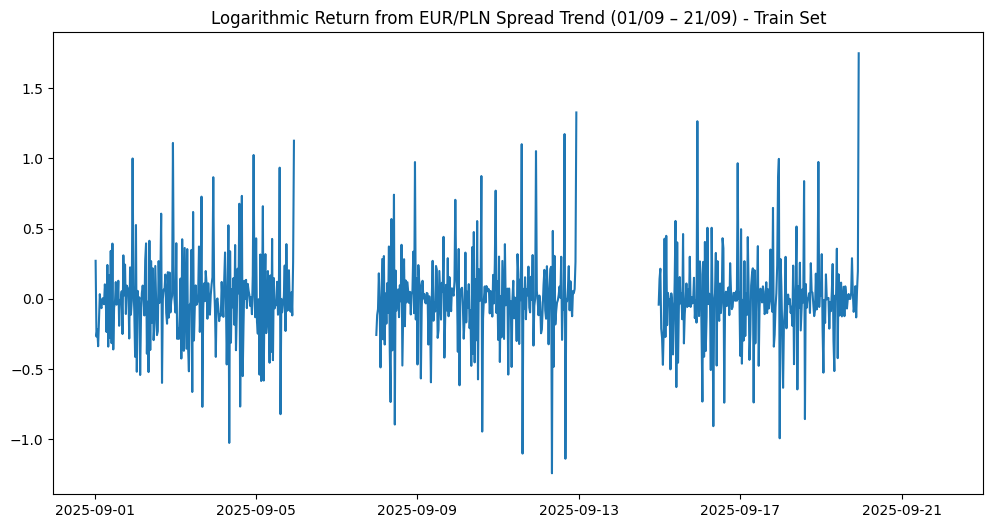

In [16]:
plt.figure(figsize = (12, 6))
plt.plot(train['spread'])
plt.title('EUR/PLN Spread Trend (01/09 – 21/09) from Train Set')
plt.show()

plt.figure(figsize = (12, 6))
plt.plot(np.log(train['spread']).diff())
plt.title('Logarithmic Return from EUR/PLN Spread Trend (01/09 – 21/09) - Train Set')
plt.show()

In [17]:
print("Basic statistics:")
print(np.log(train['mid']).diff().dropna().describe())
print("\nSkewness:", stats.skew(np.log(train['mid']).diff().dropna()))
print("Kurtosis:", stats.kurtosis(np.log(train['mid']).diff().dropna()))

Basic statistics:
count    7.160000e+02
mean    -1.012875e-07
std      3.068215e-04
min     -1.373980e-03
25%     -1.234690e-04
50%     -3.521781e-06
75%      1.151787e-04
max      1.433087e-03
Name: mid, dtype: float64

Skewness: 0.21297350877075052
Kurtosis: 3.3280162945770515


From the above statistics, it reveals that the minimum and maximum values have occasional large moves relative to the standard deviation which suggests that there might be some extreme fluctuations and potentially heavy-tailed behaviour. Standard deviation in the train is very small which reflects that there could be the relatively stable nature of EUR/PLN at a 30-minute aggregation.

In term of skewness, the value close to zero means the distribution is nearly symmetric. A positive value (0.21) indicates slightly more frequent or slightly larger positive returns than negative ones but the effect can still be small. It is possible that there is no strong asymmetry in returns.

It is significant to note that leptokurtosis (kurtosis > 3) is another stylised fact in financial data. It means that a value more than 3, which indicates leptokurtosis, shows heavy tails, fat tails and more extreme events than normal. Since the kurtosis of 3.33 is slightly above 3, it suggests mild heavy-tailed behaviour.

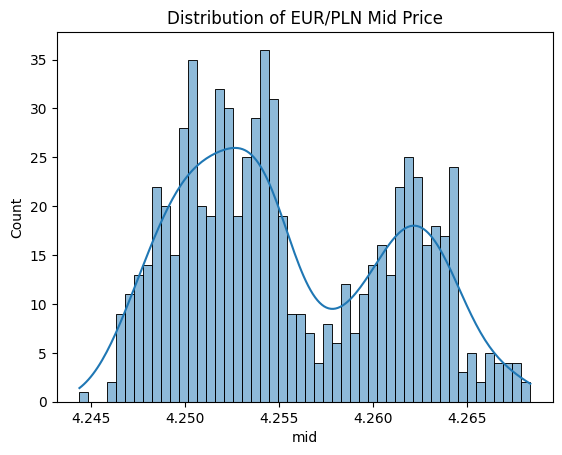

In [18]:
sns.histplot(train['mid'], kde = True, bins = 50)
plt.title("Distribution of EUR/PLN Mid Price")
plt.show()

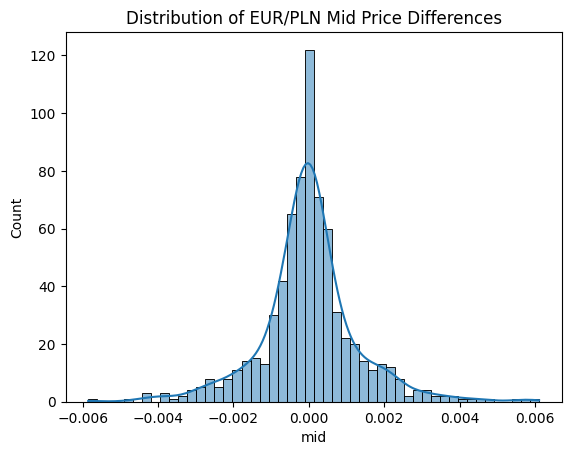

In [19]:
sns.histplot(train['mid'].diff(), kde = True, bins = 50)
plt.title("Distribution of EUR/PLN Mid Price Differences")
plt.show()

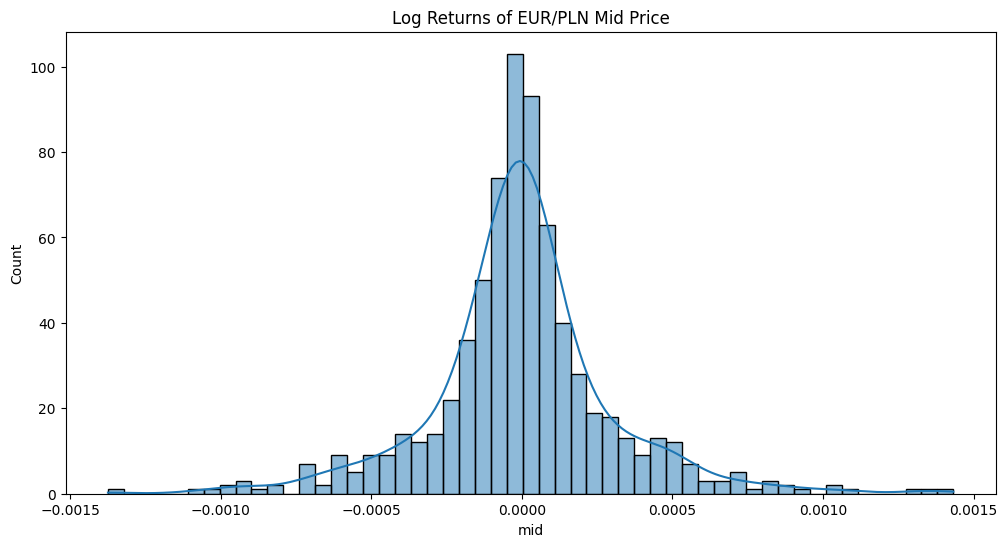

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(np.log(train['mid']).diff().dropna(), kde = True)
plt.title('Log Returns of EUR/PLN Mid Price')
plt.show()

## 5. Decision on Choosing Proper Model

First of all, a Jarque–Bera (JB) test has to be checked for whether the return series is normally distributed based on its skewness and kurtosis. It has to be done before performing an ACF (Autocorrelation Function) analysis. It is crucial because classical ACF confidence intervals assume normality while non-normal returns can distort ACF interpretation. 

In [21]:
# Jarque - Bera test
jb_test = stats.jarque_bera(np.log(train['mid']).diff().dropna())
print(f"Jarque-Bera test statistics: {jb_test[0]:.2f}")
print(f"p-value: {jb_test[1]:.2e}")

Jarque-Bera test statistics: 335.84
p-value: 1.19e-73


Here are the hypotheses for JB test:

H0: There is normality.

H1: The data does not follow a normal distribution.

The p value is below 0.05, which means to reject the null hypothesis of normality.

The result supports using volatility models such as GARCH, since heavy tails often signal volatility clustering and time-varying variance. Therefore, after confirming non-normality, it can proceed to inspect the ACF of returns and squared returns to diagnose potential ARCH effects.

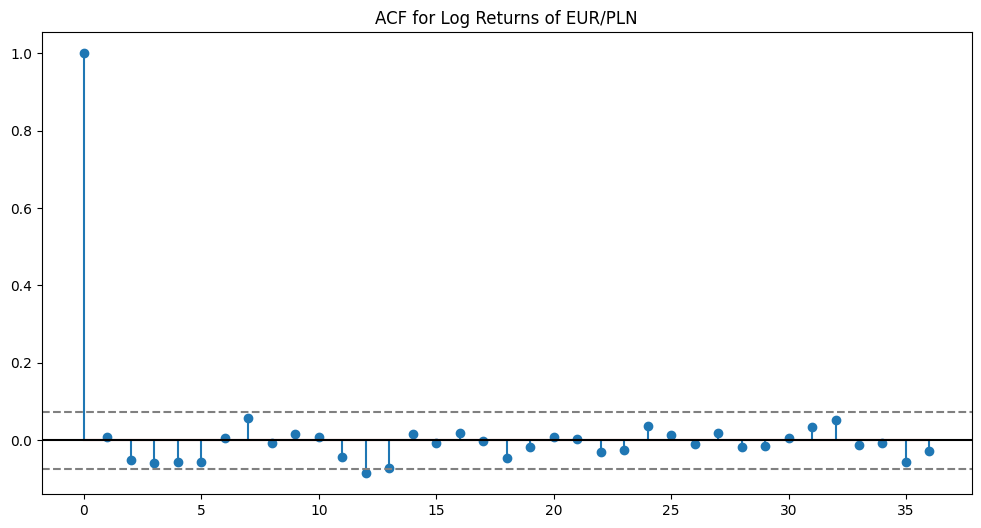

In [22]:
# autocorrelation function
acf_values = acf(np.log(train['mid']).diff().dropna(), nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Log Returns of EUR/PLN')
plt.show()

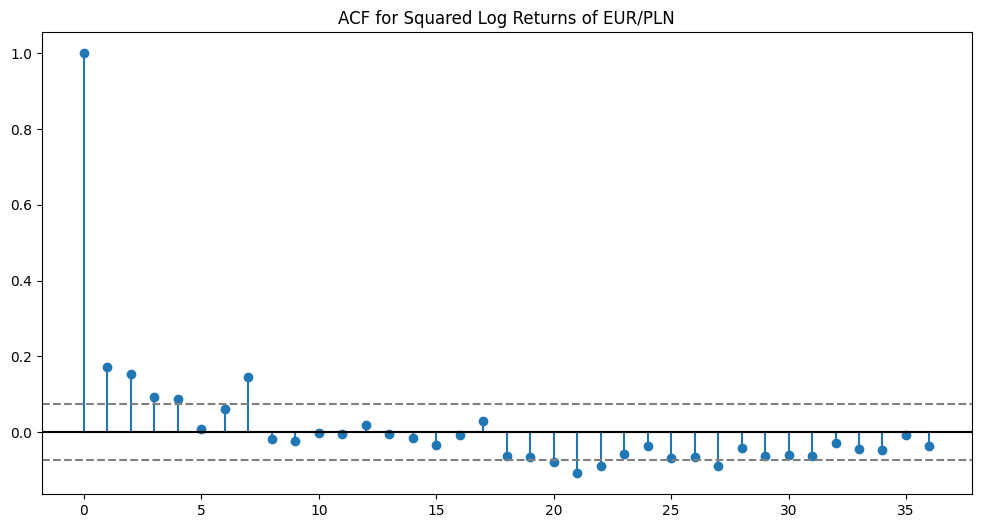

In [23]:
# Autocorrelation function - is there any dependency within the log returns?
acf_values = acf(np.log(train['mid']).diff().dropna()**2, nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Squared Log Returns of EUR/PLN')
plt.show()

In [24]:
# ARCH test (Engle's LM test)
returns_for_arch_test = np.log(train['mid']).diff().dropna()
arch_test_results = het_arch(returns_for_arch_test, nlags = 5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")

LM Statistic: 38.170
p-value: 0.000


A Engle’s ARCH LM test is conducted to confirm if there is any evidence of time-varying conditional variance. Here are the hypotheses:

H0: No ARCH effects (no conditional heteroskedasticity).

H1: ARCH effects present (volatility clustering exists).

The LM statistic shown is large and p-value is below 0.05.Null hypothesis is rejected and demonstrates a strong evidence of ARCH effects in the log returns. It means that the conditional variance of returns is not constant and the periods of high volatility tend to cluster. Therefore, applying a ARCH or even GARCH type model is appropriate. It can help to to model the conditional volatility of EUR/PLN returns which forms the foundation for the volatility-based trading strategy.

Right after, ARCH is firstly tried to use.

### 1. ARCH (1)

A pure ARCH(1) model to the log returns tries to be fitted. This is a simple starting point to capture volatility clustering. Ljung–Box test is used to test the autocorrelation on residuals on both squared and non-squared ways. Here are the hypothese:

H0: No autocorrelation in the residuals (mean equation is correctly specified)

H1: Autocorrelation exists (mean equation may be missing predictive terms)

For the standardized residuals, it does not show significant autocorrelation since all p-values are more than 0.05 at all lags and thus it fails to reject H0. Yet, there is a significant autocorrelation that remains in the squared residuals as the p-values are less than 0.05 and thus it rejects H0 at all lags. ARCH(1) in such case is not sufficient and a higher-order ARCH(p) or a GARCH(p,q) model is needed to capture all conditional heteroskedasticity.

In [25]:
# ARCH(1)
model_arch1 = arch_model(np.log(train['mid']).diff().dropna(), vol = 'ARCH', p = 1, q = 0, rescale = False)
model_arch1 = model_arch1.fit(disp = 'off')
print(model_arch1.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                    mid   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                4800.50
Distribution:                  Normal   AIC:                          -9594.99
Method:            Maximum Likelihood   BIC:                          -9581.27
                                        No. Observations:                  716
Date:                Wed, Nov 26 2025   Df Residuals:                      715
Time:                        22:26:13   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.0129e-07  1.418e-07     -0.714      0.

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/2608553455.py:3: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  model_arch1 = model_arch1.fit(disp = 'off')


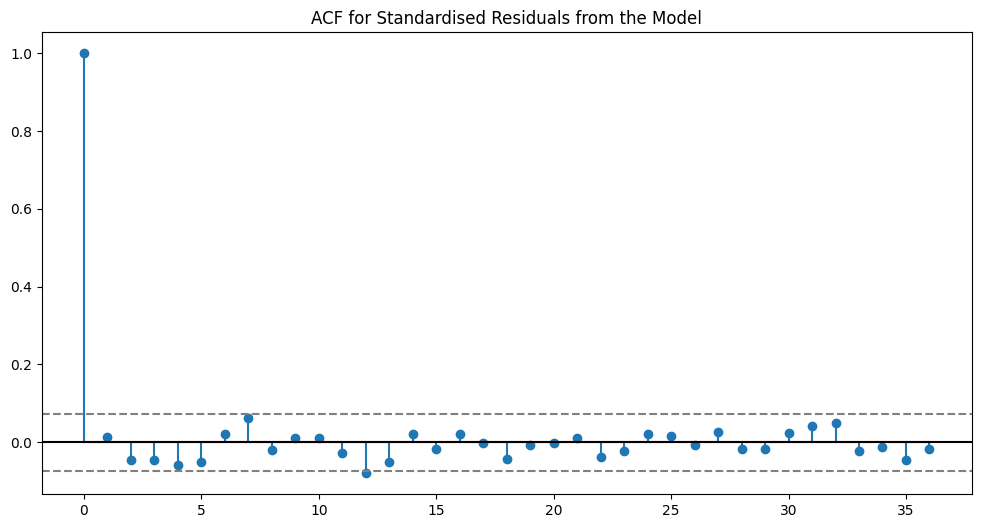

In [26]:
acf_values = acf((model_arch1.resid / model_arch1.conditional_volatility).dropna(), nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Standardised Residuals from the Model')
plt.show()

In [27]:
# Ljung-Box test for autocorrelation in standardised residuals
# autocorrelations (not rejecting null) 
acorr_ljungbox((model_arch1.resid / model_arch1.conditional_volatility).dropna(), lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,7.488736,0.186755
10,11.030474,0.355149
15,18.702406,0.227537
20,20.429071,0.431393


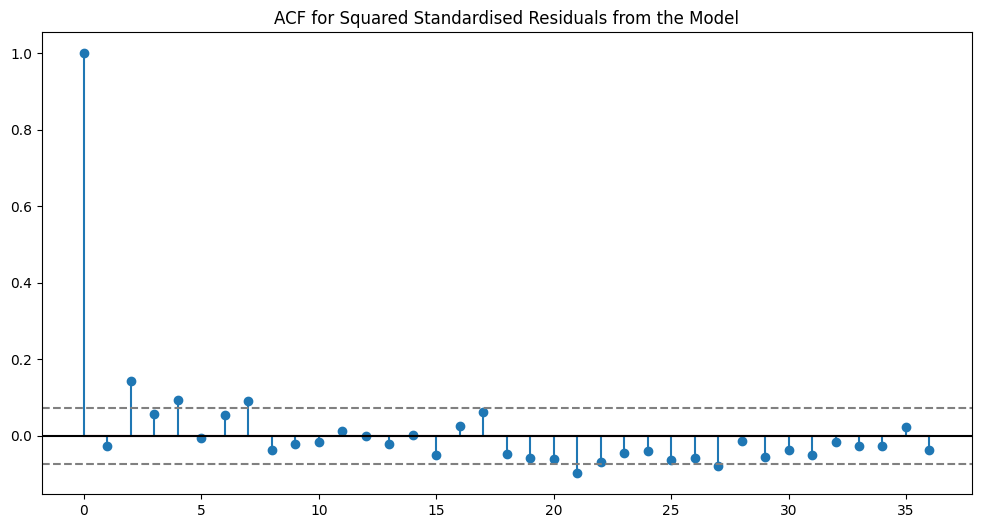

In [28]:
acf_values = acf((model_arch1.resid / model_arch1.conditional_volatility).dropna()**2, nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Squared Standardised Residuals from the Model')
plt.show()

In [29]:
# Ljung-Box test for autocorrelation in squared standardised residuals
# autocorrelations (rejecting null)
# need to add something to the variance equation
acorr_ljungbox((model_arch1.resid / model_arch1.conditional_volatility).dropna()**2, lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,24.003783,0.000217
10,33.671102,0.000210
15,36.070022,0.001727
20,45.972062,0.000813


### 2. ARCH (5)

A pure ARCH(5) model to the log returns tries to be fitted. Ljung–Box test is also used to test the autocorrelation on residuals on both squared and non-squared ways. Here are the same hypothese:

H0: No autocorrelation in the residuals (mean equation is correctly specified)

H1: Autocorrelation exists (mean equation may be missing predictive terms)

For the standardized residuals, it does not show significant autocorrelation since all p-values are more than 0.05 at all lags and thus it fails to reject H0. On the other hand, there is no significant autocorrelation that remains in the squared residuals as the p-values are all more than 0.05 and thus it fails to reject H0 at all lags. ARCH(5) in such case is sufficient. ARCH(5) already passes the diagnostics.

However, GARCH(1,1) will also be tested because it is far more parsimonious and captures the same persistence with fewer parameters. The rule here is to use the simplest model that passes the diagnostic checks and has good information criteria / parameter behaviour. A GARCH model will be run in the following section.

In [30]:
# ARCH(5)
model_arch5 = arch_model(np.log(train['mid']).diff().dropna(), vol='ARCH', p = 5, q = 0, rescale = False)
model_arch5 = model_arch5.fit(disp = 'off')
print(model_arch5.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                    mid   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                4817.35
Distribution:                  Normal   AIC:                          -9620.71
Method:            Maximum Likelihood   BIC:                          -9588.69
                                        No. Observations:                  716
Date:                Wed, Nov 26 2025   Df Residuals:                      715
Time:                        22:26:13   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.0129e-07  2.194e-07     -0.462      0.

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/3850289761.py:3: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  model_arch5 = model_arch5.fit(disp = 'off')


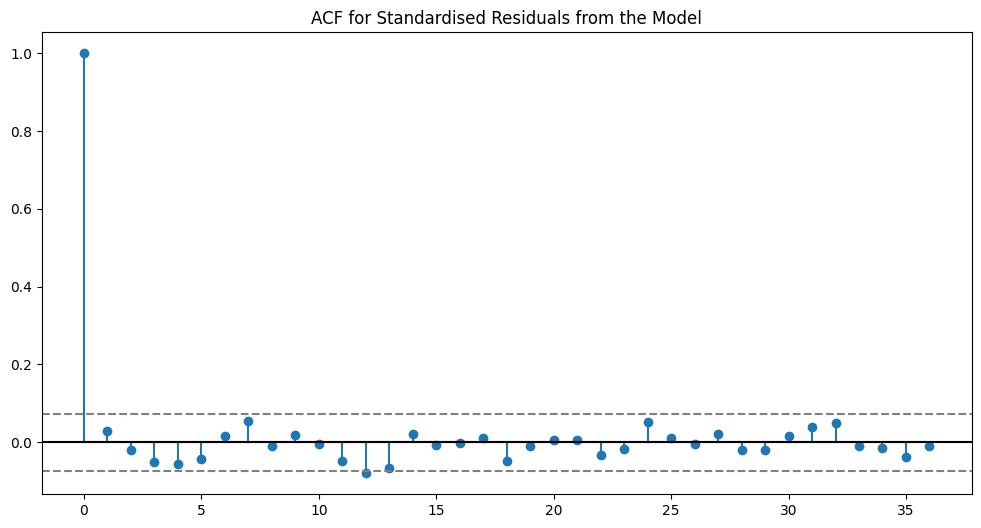

In [31]:
acf_values = acf((model_arch5.resid / model_arch5.conditional_volatility).dropna(), nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Standardised Residuals from the Model')
plt.show()

In [32]:
# Ljung-Box test for autocorrelation in standardised residuals
# autocorrelations (not rejecting null)
acorr_ljungbox((model_arch5.resid / model_arch5.conditional_volatility).dropna(), lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,6.527565,0.258212
10,9.200987,0.513141
15,19.292849,0.200769
20,21.146865,0.388534


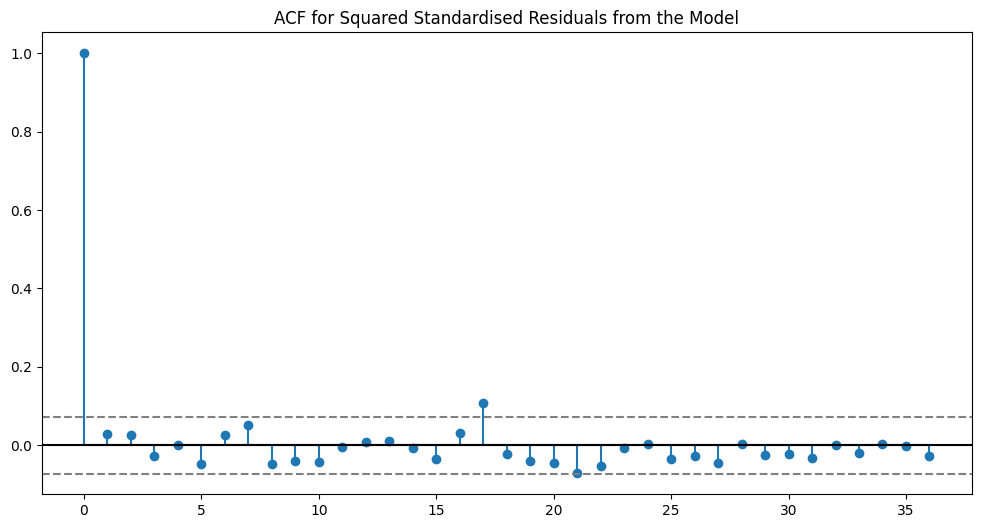

In [33]:
acf_values = acf((model_arch5.resid / model_arch5.conditional_volatility).dropna()**2, nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Squared Standardised Residuals from the Model')
plt.show()

In [34]:
# Ljung-Box test for autocorrelation in squared standardised residuals
# autocorrelations (not rejecting null)
acorr_ljungbox((model_arch5.resid / model_arch5.conditional_volatility).dropna()**2, lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,3.307577,0.652682
10,9.908512,0.448556
15,11.008602,0.751984
20,23.129941,0.282459


### 3. GARCH (1,1)

A GARCH(1,1) model to the log returns tries to be fitted. Ljung–Box test is also used to test the autocorrelation on residuals on both squared and non-squared ways. Due to the high value of kurtosis (heavy tails), t-Student distribution is set in the GARCH(1,1) model. Here are the same hypothese:

H0: No autocorrelation in the residuals (mean equation is correctly specified)

H1: Autocorrelation exists (mean equation may be missing predictive terms)

For the standardized residuals, it does not show significant autocorrelation since all p-values are more than 0.05 at all lags and thus it fails to reject H0. On the other hand, there is no significant autocorrelation that remains in the squared residuals as the p-values are all more than 0.05 and thus it fails to reject H0 at all lags. The sum of alpha and beta is less than 1 which indicates that the model is stationary in such case.

Compared to ARCH(5), GARCH(1,1) has a lower AIC/BIC than ARCH(5) in the run, so GARCH(1,1) is preferred on information-criterion grounds and it is also the standard first choice due to parameter behaviour. Additionally, Ljung-Box results for the GARCH(1,1) fit looks fine (p > 0.05) which means that no AR mean requires further. GARCH(1,1) with t-Student distribution is selected ultimately.

In [35]:
# GARCH(1,1) with constant in mean equation removed
# constant in variance equation should not be removed as then the GARCH framework is not stationary and the algorithm will not converge
model_garch11 = arch_model(np.log(train['mid']).diff().dropna(), vol = 'GARCH', p = 1, q = 1, dist = 't', rescale = False)
model_garch11 = model_garch11.fit(disp = 'off')
print(model_garch11.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          mid   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                4876.98
Distribution:      Standardized Student's t   AIC:                          -9743.97
Method:                  Maximum Likelihood   BIC:                          -9721.10
                                              No. Observations:                  716
Date:                      Wed, Nov 26 2025   Df Residuals:                      715
Time:                              22:26:13   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/796168832.py:4: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch11 = model_garch11.fit(disp = 'off')


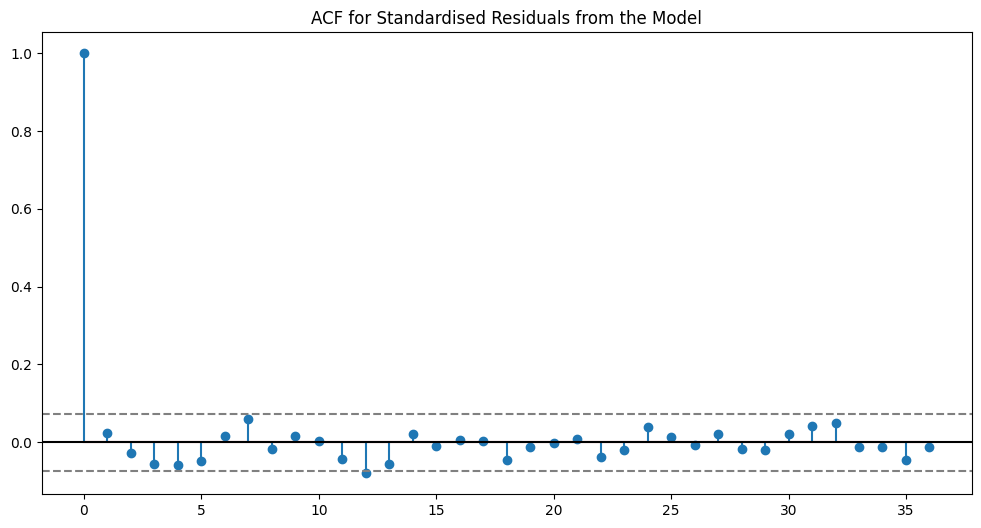

In [36]:
acf_values = acf((model_garch11.resid / model_garch11.conditional_volatility).dropna(), nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Standardised Residuals from the Model')
plt.show()

In [37]:
# Ljung-Box test for autocorrelation in standardised residuals
# autocorrelations (not rejecting null)
acorr_ljungbox((model_garch11.resid / model_garch11.conditional_volatility).dropna(), lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,7.341323,0.196468
10,10.545886,0.393973
15,19.520327,0.191116
20,21.132208,0.389388


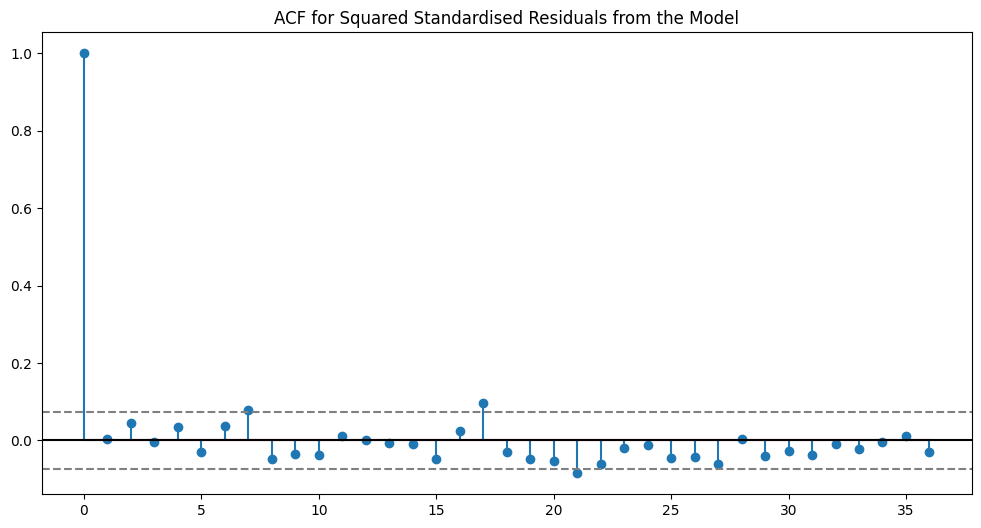

In [38]:
acf_values = acf((model_garch11.resid / model_garch11.conditional_volatility).dropna()**2, nlags = 36)
plt.figure(figsize = (12, 6))
plt.stem(range(len(acf_values)), acf_values)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y = -1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.axhline(y = 1.96/np.sqrt(len(np.log(train['mid']).diff().dropna())), linestyle = '--', color = 'gray')
plt.title('ACF for Squared Standardised Residuals from the Model')
plt.show()

In [39]:
# Ljung-Box test for autocorrelation in squared standardised residuals
# autocorrelations (not rejecting null)
acorr_ljungbox((model_garch11.resid / model_garch11.conditional_volatility).dropna()**2, lags = [5, 10, 15, 20], return_df = True)

,lb_stat,lb_pvalue
5,3.030215,0.695327
10,12.069553,0.280429
15,14.014687,0.524416
20,25.778779,0.173243


## 6. Volaility Breakout Model based on GARCH

From the steps above, it is confirmed that the GARCH(1,1) model is applicable and enough. The next step now is position generation and risk control. This is for translating the volatility signal and price movements into tradeable positions.

Below are the defines of periods when trading is not allowed (pos_flat = 1). There are time breaks during trading day, which avoid the first 5 minutes after a market break and the last 5 minutes before, flat positions during certain hours that outside of active trading hours, weekend filtering and setting abnormal spread avoidance for poor liquidity or extreme market conditions. These are risk-control rules to avoid executing trades in periods of high uncertainty or low liquidity which is also complementary to the volatility model.

Here for the time breaks during trading days are based on the European foreign exhcange market, the trading window for EUR/PLN. They correspond to the London market open time period each day, Frankfurt and Warsaw trading time per day, and Polish Zloty active hours.

In [40]:
def build_pos_flat(series, threshold):

    pos_flat = np.zeros(len(series))  # 0 = trade, 1 = no-trade

    # 1. disable trading outside European FX hours
    start = pd.to_datetime("09:00").time()
    end   = pd.to_datetime("18:00").time()
    
    time_ = series.index.time
    pos_flat[(time_ < start) | (time_ > end)] = 1 # no trading before 9:00 or after 18:00

    # 2. disable weekends
    dweek = series.index.dayofweek  # 0=Mon, ..., 6=Sun
    pos_flat[dweek >= 5] = 1  # Saturday/Sunday

    # 3. disable early Monday (low liquidity)
    pos_flat[(dweek == 0) & (time_ < start)] = 1 # early Monday hours often have low liquidity in FX markets so Monday before 09:00 as no-trade.

    # 4. disable Friday after close
    pos_flat[(dweek == 4) & (time_ > end)] = 1

    # 5. disable abnormal-spread periods
    pos_flat[series > threshold] = 1

    return pos_flat


Here are the core trading logic that to handle both mean-reversion and momentum strategies. It is also used to generate forecasted return, GARCH-based signal, or price deviation.

In [41]:
# define the function for position calculation
def position(signal, lower, upper, pos_flat, strategy):
    
    if strategy not in ["mom", "mr"]:
        print("Strategy parameter incorrect. Please use 'mom' or 'mr'!")
        return None
    
    # initialize position array
    position = np.zeros(len(signal))
    
    for i in range(1, len(signal)):
        
        # flat/no-trade periods
        if pos_flat[i] == 1:
            position[i] = 0
        else:
            # check for missing values
            if not np.isnan(signal.iloc[i-1]) and not np.isnan(upper.iloc[i-1]) and not np.isnan(lower.iloc[i-1]):
                
                if position[i-1] == 0:
                    if signal.iloc[i-1] > upper.iloc[i-1]:
                        position[i] = -1
                    elif signal.iloc[i-1] < lower.iloc[i-1]:
                        position[i] = 1
                
                elif position[i-1] == -1:
                    if signal.iloc[i-1] > lower.iloc[i-1]:
                        position[i] = -1
                    elif signal.iloc[i-1] < lower.iloc[i-1]:
                        position[i] = 1
                
                elif position[i-1] == 1:
                    if signal.iloc[i-1] < upper.iloc[i-1]:
                        position[i] = 1
                    elif signal.iloc[i-1] > upper.iloc[i-1]:
                        position[i] = -1
            else:
                position[i] = position[i-1]
    
    # reverse position for momentum strategy
    if strategy == "mom":
        position = -position
    
    return position

### 1. Point Value = 100000

Now, a GARCH(1,1) model is used for volatility forecasts in the defined trading strategy. THe GARCH model will influence the signals and thresholds, by estimating the expected future volatility at each 30-minute interval in log-return units. In this breakout model, the volatility (k) is assumed as 1. If price breaks above (mid + k * volatility), buy (momentum). If it breaks below (mid − k *volatility), sell. It is actually a volatility-scaled breakout strategy. When volatility is low, then the thresholds are tight and thus it produces more frequent signals. And vice versa, when volatility is high, the thresholds are wide and thus there are fewer signals but bigger moves needed.

On the other hand, a futures contract size is assumed as 100000 EUR, which is taking the example (reference: https://www.hfeu.com/en/trading-instruments/single-product?symbol=EURPLN) from real-world of HF Markets, one of the well-regulated Forex and commodities brokers. The transaction cost is the spread cost from this broker. It assumes that a Zero/Pro account is used for the buy-sell activities due to lowest cost. According to the website, the cost per trade is spread pip value which is 17.

Based on the above settings, the net P&L for train here is 3374.5 and net sharpe ratio for train is 0.67.

In [42]:
# 1. extract conditional volatility from GARCH
cond_vol = model_garch11.conditional_volatility # daily volatility in log-returns

# convert to nominal price changes
vol_nominal = cond_vol * train['mid'] # now in the same unit as prices

# 2. define breakout levels
k = 1  # volatility multiplier
upper = train['mid'] + k * vol_nominal
lower = train['mid'] - k * vol_nominal

# 3. flat/no-trade periods
pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

# 4. generate positions based on breakout strategy
pos = position(
    signal=train['mid'].ewm(span=60).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_train,
    strategy="mom" # momentum breakout
)

# 5. calculate gross P&L
pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 100000)  # point value per contract
# future contract scale to multiply to get the true value
# 6. Sharpe ratio function
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252) # annualized Sharpe

# 7. count number of transactions
ntrans = np.abs(np.diff(pos, prepend=0))

# 8. calculate net P&L (accounting for transaction costs)
pnl_net = pnl_gross - ntrans * 17 # transaction cost per contract

sr_net = mySR(pnl_net, 252)

# 9. print summary
print("Gross P&L (train):", np.round(pnl_gross.sum(), 2))
print("Gross Sharpe (train):", np.round(sr_gross, 2))
print("Number of transactions (train):", ntrans.sum())
print("Net P&L (train):", np.round(pnl_net.sum(), 2))
print("Net Sharpe (train):", np.round(sr_net, 2))


Gross P&L (train): 4394.5
Gross Sharpe (train): 0.87
Number of transactions (train): 60.0
Net P&L (train): 3374.5
Net Sharpe (train): 0.67


Here is a loop to test different volatility multipliers k = 1, 2, ..., 9 to find the value that produces the highest Sharpe ratio for the breakout strategy. It is important to note that larger k will be wider bands, which means fewer trades but higher conviction. Smaller k will be tighter bands which means more trades but more noise.

   k  Sharpe (Net)  Sharpe (Gross)  Total PnL (Net)  Total PnL (Gross)
3  4      0.717919        0.828716           2290.5             2664.5
4  5      0.708877        0.795741           1507.5             1711.5
0  1      0.669868        0.869826           3374.5             4394.5
1  2      0.331854        0.472007           1527.5             2173.5
2  3      0.284816        0.404762           1210.5             1720.5
5  6      0.081237        0.151613            114.0              216.0
6  7      0.061167        0.095607             58.0               92.0
7  8           NaN             NaN              0.0                0.0
8  9           NaN             NaN              0.0                0.0


/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1717541911.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)
/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1717541911.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


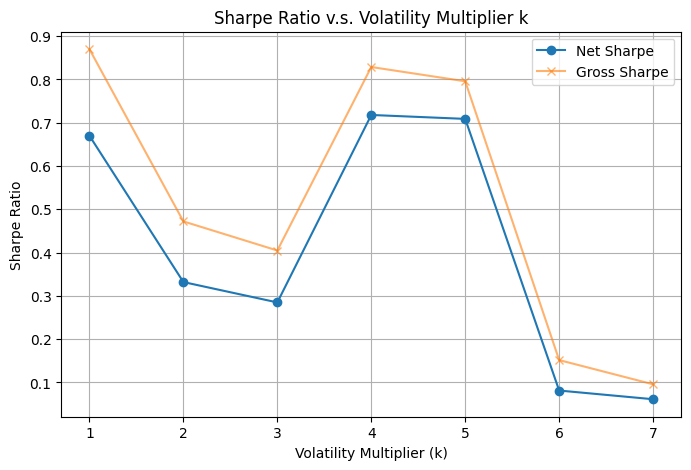

In [43]:
# define a grid of volatility multipliers to test
k_values = np.arange(1, 10, 1)  # try k = 1 - 9

results = []  # to store results for each k

# define Sharpe ratio function
def mySR(x, scale=252):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

# conditional volatility from GARCH (already fitted)
cond_vol = model_garch11.conditional_volatility
vol_nominal = cond_vol * train['mid']

# loop over each candidate k
for k in k_values:
    # 1. define breakout levels
    upper = train['mid'] + k * vol_nominal
    lower = train['mid'] - k * vol_nominal

    # 2. flat/no-trade periods
    pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

    # 3. generate positions
    pos = position(
        signal=train['mid'].ewm(span=60).mean(),
        lower=lower,
        upper=upper,
        pos_flat=pos_flat_train,
        strategy="mom"
    )

    # 4. calculate P&L
    pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 100000) # point value per contract
    ntrans = np.abs(np.diff(pos, prepend=0))
    pnl_net = pnl_gross - ntrans * 17 # transaction cost per contract

    # 5. compute Sharpe
    sr_net = mySR(pnl_net, 252)
    sr_gross = mySR(pnl_gross, 252)

    # 6. store results
    results.append({
        'k': k,
        'Sharpe (Net)': sr_net,
        'Sharpe (Gross)': sr_gross,
        'Total PnL (Net)': np.nansum(pnl_net),
        'Total PnL (Gross)': np.nansum(pnl_gross)
    })

# convert results to DataFrame
res_df = pd.DataFrame(results)

# display table sorted by best Sharpe
print(res_df.sort_values('Sharpe (Net)', ascending=False))

# plot Sharpe vs k
plt.figure(figsize=(8, 5))
plt.plot(res_df['k'], res_df['Sharpe (Net)'], marker='o', label='Net Sharpe')
plt.plot(res_df['k'], res_df['Sharpe (Gross)'], marker='x', label='Gross Sharpe', alpha=0.6)
plt.xlabel('Volatility Multiplier (k)')
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio v.s. Volatility Multiplier k')
plt.legend()
plt.grid(True)
plt.show()

From the results and plot above, it reveals that k = 4 gives the best Sharpe ratio (1.22) which is kind of solid. k = 1 gives highest total PnL but worse Sharpe ratio. It might imply that the strategy is more volatile with k = 1. k > 7 produces no trades which means the breakout bands are too wide. 

Too small k will cause overtrading. Too large k will generate no signals. In such case, volatility multipliers with 4 and 5 will be seelcted for the future model. Moderate values for k work better.

In [44]:
results = []
for k in [4, 5]:
    for signal_span in [15, 25, 30, 35, 45]:
        for strategy in ["mom", "mr"]:

            print(k, signal_span, strategy)

            # 1. extract conditional volatility from GARCH
            cond_vol = model_garch11.conditional_volatility # daily volatility in log-returns

            # convert to nominal price changes
            vol_nominal = cond_vol * train['mid'] # now in the same unit as prices

            # 2. define breakout levels
            upper = train['mid'] + k * vol_nominal
            lower = train['mid'] - k * vol_nominal

            # 3. flat/no-trade periods
            pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

            # 4. generate positions based on breakout strategy
            pos = position(
                signal=train['mid'].ewm(span=signal_span).mean(),
                lower=lower,
                upper=upper,
                pos_flat=pos_flat_train,
                strategy=strategy
            )

            # 5. calculate gross P&L
            pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 100000)  # point value for contract

            # 6. Sharpe ratio function
            def mySR(x, scale):
                return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

            sr_gross = mySR(pnl_gross, 252) # annualized Sharpe

            # 7. count number of transactions
            ntrans = np.abs(np.diff(pos, prepend=0))

            # 8. calculate net P&L (accounting for transaction costs)
            pnl_net = pnl_gross - ntrans * 17 # transaction cost per contract

            sr_net = mySR(pnl_net, 252)

            results.append([k, signal_span, strategy, np.round(pnl_gross.sum(), 2), np.round(sr_gross, 2), ntrans.sum(), np.round(pnl_net.sum(), 2), np.round(sr_net, 2)])

4 15 mom
4 15 mr
4 25 mom
4 25 mr
4 30 mom
4 30 mr
4 35 mom
4 35 mr
4 45 mom
4 45 mr
5 15 mom
5 15 mr
5 25 mom
5 25 mr
5 30 mom
5 30 mr
5 35 mom
5 35 mr
5 45 mom
5 45 mr


/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1535882051.py:35: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)
/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1535882051.py:35: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


In [45]:
results_df = pd.DataFrame(results)
results_df.columns = ['k', 'signal_span', 'strategy', 'pnl_gross', 'sr_gross', 'ntrans', 'pnl_net', 'sr_net']

In [46]:
results_df.sort_values(by = 'pnl_net', ascending = False).head()

,k,signal_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
8,4,45,mom,2243.5,0.72,16.0,1971.5,0.64
2,4,25,mom,2031.0,0.87,14.0,1793.0,0.78
4,4,30,mom,2031.0,0.87,14.0,1793.0,0.78
6,4,35,mom,2031.0,0.87,14.0,1793.0,0.78
0,4,15,mom,1684.0,0.87,10.0,1514.0,0.79


In [47]:
results_df.sort_values(by = 'sr_net', ascending = False).head()

,k,signal_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
0,4,15,mom,1684.0,0.87,10.0,1514.0,0.79
2,4,25,mom,2031.0,0.87,14.0,1793.0,0.78
4,4,30,mom,2031.0,0.87,14.0,1793.0,0.78
6,4,35,mom,2031.0,0.87,14.0,1793.0,0.78
18,5,45,mom,1711.5,0.80,12.0,1507.5,0.71


After performing a multi-parameter grid search with volatility multiplier, smoothing window signal span and the strategy types for momentum breakout and mean-reversion, it is able to determine which combination produces the best profit and Sharpe ratio for the GARCH volatility breakout system.

From the results above, it predicts that k = 4, signal span = 45 and momemtum strategy can generate the highest net profit, while k = 4, signal span = 25 and momemtum strategy can provide the highest Sharpe ratio.

Referring to the suggestions, the followings run the out-sample estimations to get the net profit and Sharpe ratio with these two combinations of parameters.

In [48]:
# optimal parameters for net PnL from in-sample
point_value = 100000
trans_cost = 17
k = 4
signal_span = 45
strategy = "mom"

# array to store predicted volatility
vol_pred = np.zeros(len(test['mid']))

# start with training data
full_series = train['mid'].copy()

# define refit frequency
refit_freq = 60*24   # fit model only every 60*24 obs.

res = None  # store last fitted model

for t in range(len(test['mid'])):
    # add new observation
    full_series = pd.concat([full_series, test['mid'].iloc[t:t+1]])
    returns = np.log(full_series).diff().dropna()

    # only refit every refit_freq steps or at the first step
    if (t % refit_freq == 0) or (res is None):
        am = arch_model(returns, vol='GARCH', p=1, q=1, dist = 't', rescale=False)
        res = am.fit(disp='off')

    # one-step-ahead forecast from current model
    forecast = res.forecast(horizon=1, reindex=False)
    vol_pred[t] = np.sqrt(forecast.variance.values[-1, 0])

# convert to nominal price changes
vol_nominal = test['mid'] * vol_pred

# define breakout levels
upper = test['mid'] + k * vol_nominal
lower = test['mid'] - k * vol_nominal

# flat/no-trade periods
pos_flat_test = build_pos_flat(test['mid'], train['mid'].quantile(0.95))

# generate positions
pos = position(
    signal=test['mid'].ewm(span=signal_span).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_test,
    strategy=strategy
)

# calculate P&L
pnl_gross = np.where(np.isnan(pos * test['mid'].diff()), 0, pos * test['mid'].diff() * point_value)
ntrans = np.abs(np.diff(pos, prepend=0))
pnl_net = pnl_gross - ntrans * trans_cost

# Sharpe ratio
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252)
sr_net = mySR(pnl_net, 252)

# summary
print("Gross P&L (test):", np.round(pnl_gross.sum(),2))
print("Gross Sharpe (test):", np.round(sr_gross,2))
print("Number of transactions (test):", ntrans.sum())
print("Net P&L (test):", np.round(pnl_net.sum(),2))
print("Net Sharpe (test):", np.round(sr_net,2))

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/2874121632.py:27: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp='off')


Gross P&L (test): 51.0
Gross Sharpe (test): 0.06
Number of transactions (test): 2.0
Net P&L (test): 17.0
Net Sharpe (test): 0.02


In [49]:
# optimal parameters for net PnL from in-sample
point_value = 100000
trans_cost = 17
k = 4
signal_span = 25
strategy = "mom"

# array to store predicted volatility
vol_pred = np.zeros(len(test['mid']))

# start with training data
full_series = train['mid'].copy()

# define refit frequency
refit_freq = 60*24   # fit model only every 60*24 obs.

res = None  # store last fitted model

for t in range(len(test['mid'])):
    # add new observation
    full_series = pd.concat([full_series, test['mid'].iloc[t:t+1]])
    returns = np.log(full_series).diff().dropna()

    # only refit every refit_freq steps or at the first step
    if (t % refit_freq == 0) or (res is None):
        am = arch_model(returns, vol='GARCH', p=1, q=1, dist = 't', rescale=False)
        res = am.fit(disp='off')

    # one-step-ahead forecast from current model
    forecast = res.forecast(horizon=1, reindex=False)
    vol_pred[t] = np.sqrt(forecast.variance.values[-1, 0])

# convert to nominal price changes
vol_nominal = test['mid'] * vol_pred

# define breakout levels
upper = test['mid'] + k * vol_nominal
lower = test['mid'] - k * vol_nominal

# flat/no-trade periods
pos_flat_test = build_pos_flat(test['mid'], train['mid'].quantile(0.95))

# generate positions
pos = position(
    signal=test['mid'].ewm(span=signal_span).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_test,
    strategy=strategy
)

# calculate P&L
pnl_gross = np.where(np.isnan(pos * test['mid'].diff()), 0, pos * test['mid'].diff() * point_value)
ntrans = np.abs(np.diff(pos, prepend=0))
pnl_net = pnl_gross - ntrans * trans_cost

# Sharpe ratio
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252)
sr_net = mySR(pnl_net, 252)

# summary
print("Gross P&L (test):", np.round(pnl_gross.sum(),2))
print("Gross Sharpe (test):", np.round(sr_gross,2))
print("Number of transactions (test):", ntrans.sum())
print("Net P&L (test):", np.round(pnl_net.sum(),2))
print("Net Sharpe (test):", np.round(sr_net,2))

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1718361293.py:27: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp='off')


Gross P&L (test): 384.0
Gross Sharpe (test): 0.69
Number of transactions (test): 2.0
Net P&L (test): 350.0
Net Sharpe (test): 0.64


From the two outcomes of the out-sample datasets, it proves that the second combination (k = 4, signal span = 25 and momemtum strategy) can successfully generate higher net profit and Sharpe ratio than the first combination (k = 4, signal span = 45 and momemtum strategy).

The net profit for the target time period in the project will be 350 PLN and the Sharpe ratio is 0.64, which is close to 1 and means that it is generating a reasonable return for the level of risk (volatility) taken. It is pretty similar to the result of in-sample train set.

### 2. Point Value = 1

When the point value is set as 100000, this is actually a futures contract scaling factor, which is just like future contract scale to multiply some values to get the true value. The unit of profit and lost will be expressed in PLN. Yet, it will hide the economic meaning of the strategy depends heavily on the contract size

If the point value is set as 1, it means that the model will work in pure price units but not contract notional. It can measure the raw performance of the strategy and the model. In such case, if point value si 1, then the transaction cost should also be in price units, not PLN. Everything stays in pure price unit and the Sharpe ratio will be unaffected by the contract size. 

In real world, the currency exchange cost is usually the interbank rate * 0.5%, according to Dukascopy website (reference: https://www.dukascopy.bank/fees/#trans-fees). Here, the spread will be used as transaction cost, which spread is generally an inherent cost of trading. It is believed that the use of spread with point value = 1 makes sense in the model and strategy.

The steps are more or less the same as mentioned above.

In [50]:
# 1. extract conditional volatility from GARCH
cond_vol = model_garch11.conditional_volatility # daily volatility in log-returns

# convert to nominal price changes
vol_nominal = cond_vol * train['mid'] # now in the same unit as prices

# 2. define breakout levels
k = 1  # volatility multiplier
upper = train['mid'] + k * vol_nominal
lower = train['mid'] - k * vol_nominal

# 3. flat/no-trade periods
pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

# 4. generate positions based on breakout strategy
pos = position(
    signal=train['mid'].ewm(span=60).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_train,
    strategy="mom" # momentum breakout
)

# 5. calculate gross P&L
pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 1) 
# future contract scale to multiply to get the true value
# 6. Sharpe ratio function
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252) # annualized Sharpe

# 7. count number of transactions
ntrans = np.abs(np.diff(pos, prepend=0))

# 8. calculate net P&L (accounting for transaction costs)
pnl_net = pnl_gross - ntrans * train['spread']

sr_net = mySR(pnl_net, 252)

# 9. print summary
print("Gross P&L (train):", np.round(pnl_gross.sum(), 2))
print("Gross Sharpe (train):", np.round(sr_gross, 2))
print("Number of transactions (train):", ntrans.sum())
print("Net P&L (train):", np.round(pnl_net.sum(), 2))
print("Net Sharpe (train):", np.round(sr_net, 2))


Gross P&L (train): 0.04
Gross Sharpe (train): 0.87
Number of transactions (train): 60.0
Net P&L (train): -0.04
Net Sharpe (train): -0.8


When the volatility multiplier is assumed as 1, it seems that there is only loss and the Sharpe ratio is in negative.

Right now below, there is a loop for checking which volatility multiplier will be the best for forecasting.

   k  Sharpe (Net)  Sharpe (Gross)  Total PnL (Net)  Total PnL (Gross)
4  5     -0.084268        0.795741        -0.001585           0.017115
3  4     -0.194067        0.828716        -0.005395           0.026645
6  7     -0.234927        0.095607        -0.001850           0.000920
5  6     -0.628100        0.151613        -0.008100           0.002160
2  3     -0.676347        0.404762        -0.025855           0.017205
1  2     -0.764725        0.472007        -0.031855           0.021735
0  1     -0.800117        0.869826        -0.036795           0.043945
7  8           NaN             NaN         0.000000           0.000000
8  9           NaN             NaN         0.000000           0.000000


/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1682702030.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)
/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1682702030.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


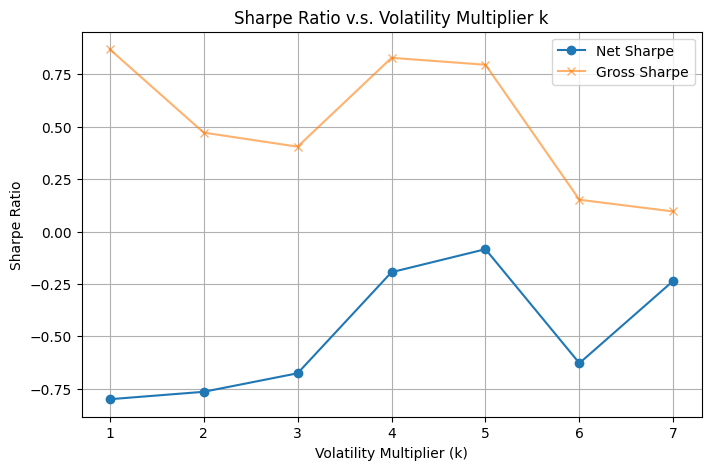

In [51]:
# define a grid of volatility multipliers to test
k_values = np.arange(1, 10, 1)

results = []  # to store results for each k

# define Sharpe ratio function
def mySR(x, scale=252):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

# conditional volatility from GARCH (already fitted)
cond_vol = model_garch11.conditional_volatility
vol_nominal = cond_vol * train['mid']

# loop over each candidate k
for k in k_values:
    # 1. define breakout levels
    upper = train['mid'] + k * vol_nominal
    lower = train['mid'] - k * vol_nominal

    # 2. flat/no-trade periods
    pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

    # 3. generate positions
    pos = position(
        signal=train['mid'].ewm(span=60).mean(),
        lower=lower,
        upper=upper,
        pos_flat=pos_flat_train,
        strategy="mom"
    )

    # 4. calculate P&L
    pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 1)
    ntrans = np.abs(np.diff(pos, prepend=0))
    pnl_net = pnl_gross - ntrans * train['spread']

    # 5. compute Sharpe
    sr_net = mySR(pnl_net, 252)
    sr_gross = mySR(pnl_gross, 252)

    # 6. store results
    results.append({
        'k': k,
        'Sharpe (Net)': sr_net,
        'Sharpe (Gross)': sr_gross,
        'Total PnL (Net)': np.nansum(pnl_net),
        'Total PnL (Gross)': np.nansum(pnl_gross)
    })

# convert results to DataFrame
res_df = pd.DataFrame(results)

# display table sorted by best Sharpe
print(res_df.sort_values('Sharpe (Net)', ascending=False))

# plot Sharpe vs k
plt.figure(figsize=(8, 5))
plt.plot(res_df['k'], res_df['Sharpe (Net)'], marker='o', label='Net Sharpe')
plt.plot(res_df['k'], res_df['Sharpe (Gross)'], marker='x', label='Gross Sharpe', alpha=0.6)
plt.xlabel('Volatility Multiplier (k)')
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio v.s. Volatility Multiplier k')
plt.legend()
plt.grid(True)
plt.show()

Similarly, there is no trade happened after k = 7. And the moderate multipliers 4 and 5 seem work the best across all the multipliers.

The next step is to proceed with the k = 4 and k = 5 to check which combinations of parameters will be the best in performing in the specific time period.

In [52]:
results = []
for k in [4, 5]:
    for signal_span in [15, 25, 30, 35, 45]:
        for strategy in ["mom", "mr"]:

            print(k, signal_span, strategy)

            # 1. extract conditional volatility from GARCH
            cond_vol = model_garch11.conditional_volatility # daily volatility in log-returns

            # convert to nominal price changes
            vol_nominal = cond_vol * train['mid'] # now in the same unit as prices

            # 2. define breakout levels
            upper = train['mid'] + k * vol_nominal
            lower = train['mid'] - k * vol_nominal

            # 3. flat/no-trade periods
            pos_flat_train = build_pos_flat(train['mid'], train['mid'].quantile(0.95))

            # 4. generate positions based on breakout strategy
            pos = position(
                signal=train['mid'].ewm(span=signal_span).mean(),
                lower=lower,
                upper=upper,
                pos_flat=pos_flat_train,
                strategy=strategy
            )

            # 5. calculate gross P&L
            pnl_gross = np.where(np.isnan(pos * train['mid'].diff()), 0, pos * train['mid'].diff() * 1)

            # 6. Sharpe ratio function
            def mySR(x, scale):
                return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

            sr_gross = mySR(pnl_gross, 252) # annualized Sharpe

            # 7. count number of transactions
            ntrans = np.abs(np.diff(pos, prepend=0))

            # 8. calculate net P&L (accounting for transaction costs)
            pnl_net = pnl_gross - ntrans * train['spread']

            sr_net = mySR(pnl_net, 252)

            results.append([k, signal_span, strategy, np.round(pnl_gross.sum(), 2), np.round(sr_gross, 2), ntrans.sum(), np.round(pnl_net.sum(), 2), np.round(sr_net, 2)])

4 15 mom
4 15 mr
4 25 mom
4 25 mr
4 30 mom
4 30 mr
4 35 mom
4 35 mr
4 45 mom
4 45 mr
5 15 mom
5 15 mr
5 25 mom
5 25 mr
5 30 mom
5 30 mr
5 35 mom
5 35 mr
5 45 mom
5 45 mr


/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1108895531.py:35: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)
/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1108895531.py:35: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


In [53]:
results_df = pd.DataFrame(results)
results_df.columns = ['k', 'signal_span', 'strategy', 'pnl_gross', 'sr_gross', 'ntrans', 'pnl_net', 'sr_net']

In [54]:
results_df.sort_values(by = 'pnl_net', ascending = False).head()

,k,signal_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
0,4,15,mom,0.02,0.87,10.0,0.0,0.17
8,4,45,mom,0.02,0.72,16.0,-0.0,-0.08
18,5,45,mom,0.02,0.80,12.0,-0.0,-0.08
16,5,35,mom,0.02,0.78,14.0,-0.0,-0.21
14,5,30,mom,0.01,0.68,10.0,-0.0,-0.03


In [55]:
results_df.sort_values(by = 'sr_net', ascending = False).head()

,k,signal_span,strategy,pnl_gross,sr_gross,ntrans,pnl_net,sr_net
0,4,15,mom,0.02,0.87,10.0,0.0,0.17
14,5,30,mom,0.01,0.68,10.0,-0.0,-0.03
2,4,25,mom,0.02,0.87,14.0,-0.0,-0.08
18,5,45,mom,0.02,0.80,12.0,-0.0,-0.08
4,4,30,mom,0.02,0.87,14.0,-0.0,-0.08


From the results above, it predicts that k = 4, signal span = 15 and momemtum strategy can generate the highest net profit and the highest Sharpe ratio.

Referring to the suggestions, the followings run the out-sample estimations to get the net profit and Sharpe ratio with some combinations of parameters.

In [56]:
# optimal parameters for net PnL from in-sample
point_value = 1
trans_cost = test['spread']
k = 4
signal_span = 15
strategy = "mom"

# array to store predicted volatility
vol_pred = np.zeros(len(test['mid']))

# start with training data
full_series = train['mid'].copy()

# define refit frequency
refit_freq = 60*24   # fit model only every 60*24 obs.

res = None  # store last fitted model

for t in range(len(test['mid'])):
    # add new observation
    full_series = pd.concat([full_series, test['mid'].iloc[t:t+1]])
    returns = np.log(full_series).diff().dropna()

    # only refit every refit_freq steps or at the first step
    if (t % refit_freq == 0) or (res is None):
        am = arch_model(returns, vol='GARCH', p=1, q=1, dist = 't', rescale=False)
        res = am.fit(disp='off')

    # one-step-ahead forecast from current model
    forecast = res.forecast(horizon=1, reindex=False)
    vol_pred[t] = np.sqrt(forecast.variance.values[-1, 0])

# convert to nominal price changes
vol_nominal = test['mid'] * vol_pred

# define breakout levels
upper = test['mid'] + k * vol_nominal
lower = test['mid'] - k * vol_nominal

# flat/no-trade periods
pos_flat_test = build_pos_flat(test['mid'], train['mid'].quantile(0.95))

# generate positions
pos = position(
    signal=test['mid'].ewm(span=signal_span).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_test,
    strategy=strategy
)

# calculate P&L
pnl_gross = np.where(np.isnan(pos * test['mid'].diff()), 0, pos * test['mid'].diff() * point_value)
ntrans = np.abs(np.diff(pos, prepend=0))
pnl_net = pnl_gross - ntrans * trans_cost

# Sharpe ratio
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252)
sr_net = mySR(pnl_net, 252)

# summary
print("Gross P&L (test):", np.round(pnl_gross.sum(),2))
print("Gross Sharpe (test):", np.round(sr_gross,2))
print("Number of transactions (test):", ntrans.sum())
print("Net P&L (test):", np.round(pnl_net.sum(),2))
print("Net Sharpe (test):", np.round(sr_net,2))

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1148510986.py:27: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp='off')


Gross P&L (test): 0.0
Gross Sharpe (test): nan
Number of transactions (test): 0.0
Net P&L (test): 0.0
Net Sharpe (test): nan


/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/1148510986.py:59: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)


In [57]:
# optimal parameters for net PnL from in-sample
point_value = 1
trans_cost = test['spread']
k = 5
signal_span = 45
strategy = "mom"

# array to store predicted volatility
vol_pred = np.zeros(len(test['mid']))

# start with training data
full_series = train['mid'].copy()

# define refit frequency
refit_freq = 60*24   # fit model only every 60*24 obs.

res = None  # store last fitted model

for t in range(len(test['mid'])):
    # add new observation
    full_series = pd.concat([full_series, test['mid'].iloc[t:t+1]])
    returns = np.log(full_series).diff().dropna()

    # only refit every refit_freq steps or at the first step
    if (t % refit_freq == 0) or (res is None):
        am = arch_model(returns, vol='GARCH', p=1, q=1, dist = 't', rescale=False)
        res = am.fit(disp='off')

    # one-step-ahead forecast from current model
    forecast = res.forecast(horizon=1, reindex=False)
    vol_pred[t] = np.sqrt(forecast.variance.values[-1, 0])

# convert to nominal price changes
vol_nominal = test['mid'] * vol_pred

# define breakout levels
upper = test['mid'] + k * vol_nominal
lower = test['mid'] - k * vol_nominal

# flat/no-trade periods
pos_flat_test = build_pos_flat(test['mid'], train['mid'].quantile(0.95))

# generate positions
pos = position(
    signal=test['mid'].ewm(span=signal_span).mean(),
    lower=lower,
    upper=upper,
    pos_flat=pos_flat_test,
    strategy=strategy
)

# calculate P&L
pnl_gross = np.where(np.isnan(pos * test['mid'].diff()), 0, pos * test['mid'].diff() * point_value)
ntrans = np.abs(np.diff(pos, prepend=0))
pnl_net = pnl_gross - ntrans * trans_cost

# Sharpe ratio
def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

sr_gross = mySR(pnl_gross, 252)
sr_net = mySR(pnl_net, 252)

# summary
print("Gross P&L (test):", pnl_gross.sum())
print("Gross Sharpe (test):", np.round(sr_gross,2))
print("Number of transactions (test):", ntrans.sum())
print("Net P&L (test):", pnl_net.sum())
print("Net Sharpe (test):", np.round(sr_net,2))

/var/folders/dk/613rdj513rv12lwlkp2jvfdm0000gn/T/ipykernel_58952/278151505.py:27: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = am.fit(disp='off')


Gross P&L (test): 0.0038400000000002876
Gross Sharpe (test): 0.69
Number of transactions (test): 2.0
Net P&L (test): 0.001100000000000101
Net Sharpe (test): 0.22


From the two outcomes of the out-sample datasets, it seems that even the transaction effect is tiny, but there is no loss with suboptimal Sharpe ratio. The pure performance of the model is actually not bad and kinda reliable, in term of not lossing money. xD